In [ ]:
# Automatically reload the package if you edit the .py files
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.
# Import the new package name
import decipher_vz as dc_vz
import decipher_vz2 as dc_vz2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import logging
import pandas as pd
import scanpy as sc
import os
from sklearn.cluster import KMeans

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib as mpl

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.metrics import silhouette_samples

In [ ]:
dc_vz.pl.activate_journal_quality()
dc_vz2.pl.activate_journal_quality()

AttributeError: module 'decipher_vz2.plot' has no attribute 'activate_journal_quality'

# Load data

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scanpy as sc 

In [21]:
import matplotlib
print(matplotlib.__version__)
import IPython
print(IPython.__version__)

3.9.4
9.10.0


# simulated data

## Note:
Change folder location here

In [22]:
folder = "/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Adata/v-to-z"
file = "0630_vz_0.10_0.20_0.30.h5ad"
adata1 = sc.read_h5ad(f"{folder}/{file}")
adata1.uns["color_palette"] = None
color_palette = None

In [23]:
# should print identical arrays if seed is the cause
batch0 = adata1[adata1.obs["batch"] == "0.00"]
batch1 = adata1[adata1.obs["batch"] == "0.10"]
print(np.allclose(batch0.obs["latent_t"].values, batch1.obs["latent_t"].values))
# True → confirmed seed overlap

False


### Note:

Change location here too. 

In [24]:
def run_pipeline(filepath, shift):
    folder = f"/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Adata/{shift}"
    adata = sc.read_h5ad(f"{folder}/{filepath}")
    adata.uns["color_palette"] = None
    color_palette = None

    decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

    # Train Decipher
    d1, val1 = dc_vz.tl.decipher_train(
        adata, decipher_config, plot_kwargs= {"color": "shift"}, 
        batch_key="shift",
        plot_every_k_epochs=5,
    )
    return adata, d1, val1

Epoch 60 (batch 20/20) | | train elbo: 32.10 (last epoch: 32.39) | val ll: 42.92:   6%|▌         | 60/1000 [00:11<02:56,  5.32it/s]2026-06-30 16:54:08,782 | INFO : Early stopping has been triggered.
2026-06-30 16:54:08,783 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-30 16:54:08,784 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-30 16:54:08,784 | INFO : Saving decipher model with run_id 2026-06-30-16-54-08-rich-black-null.


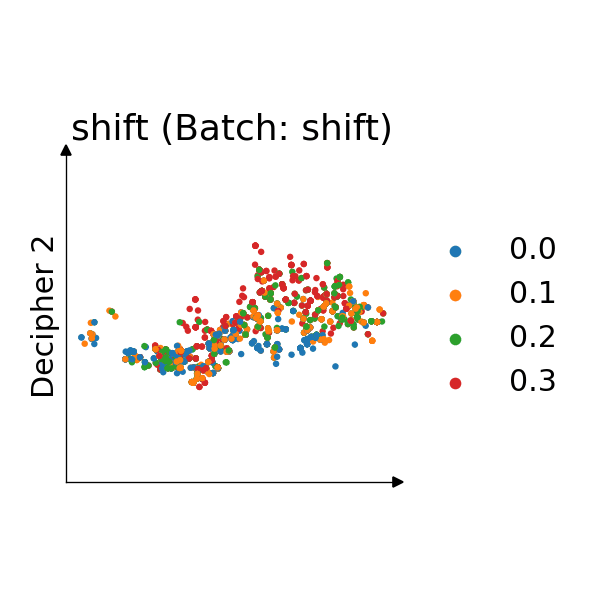

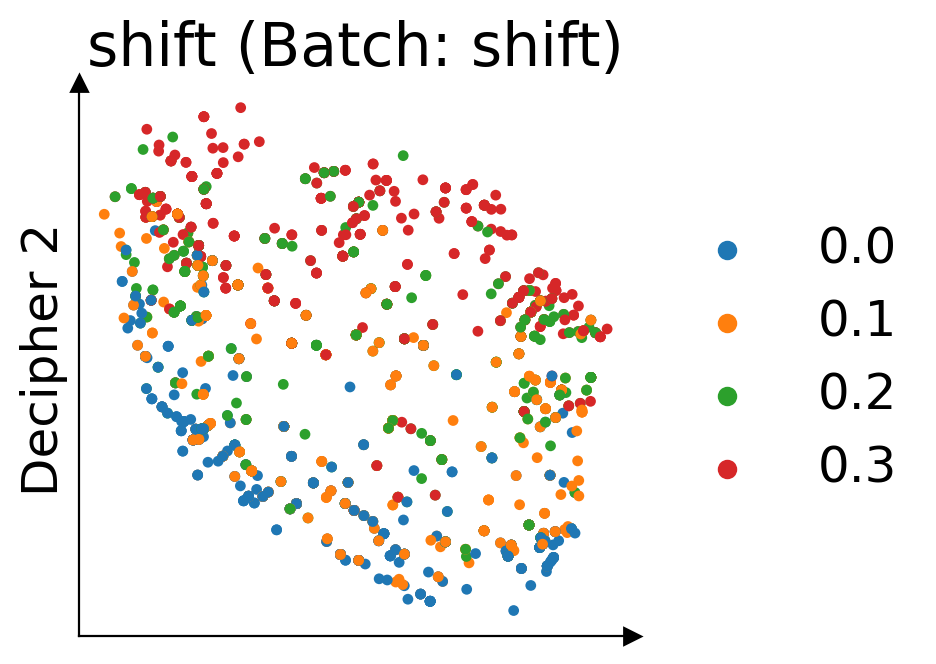

In [25]:
from decipher_vz.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

# Train Decipher
d1, val1 = dc_vz.tl.decipher_train(
    adata1, decipher_config, plot_kwargs= {"color": "shift"}, 
    batch_key="shift",
    plot_every_k_epochs=5,
)

In [26]:
def visualize_shift_latentt(adata):
    decipher_z = adata.obsm["decipher_z"]
    shift_labels = adata.obs["shift"]

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
    sc.pl.embedding(adata, basis="decipher_v", color="shift",
                    show=False, ax=axes[0], size=50)
    sc.pl.embedding(adata, basis="decipher_v", color="latent_t",
                    show=False, ax=axes[1], size=30)
    plt.tight_layout()
    plt.show()

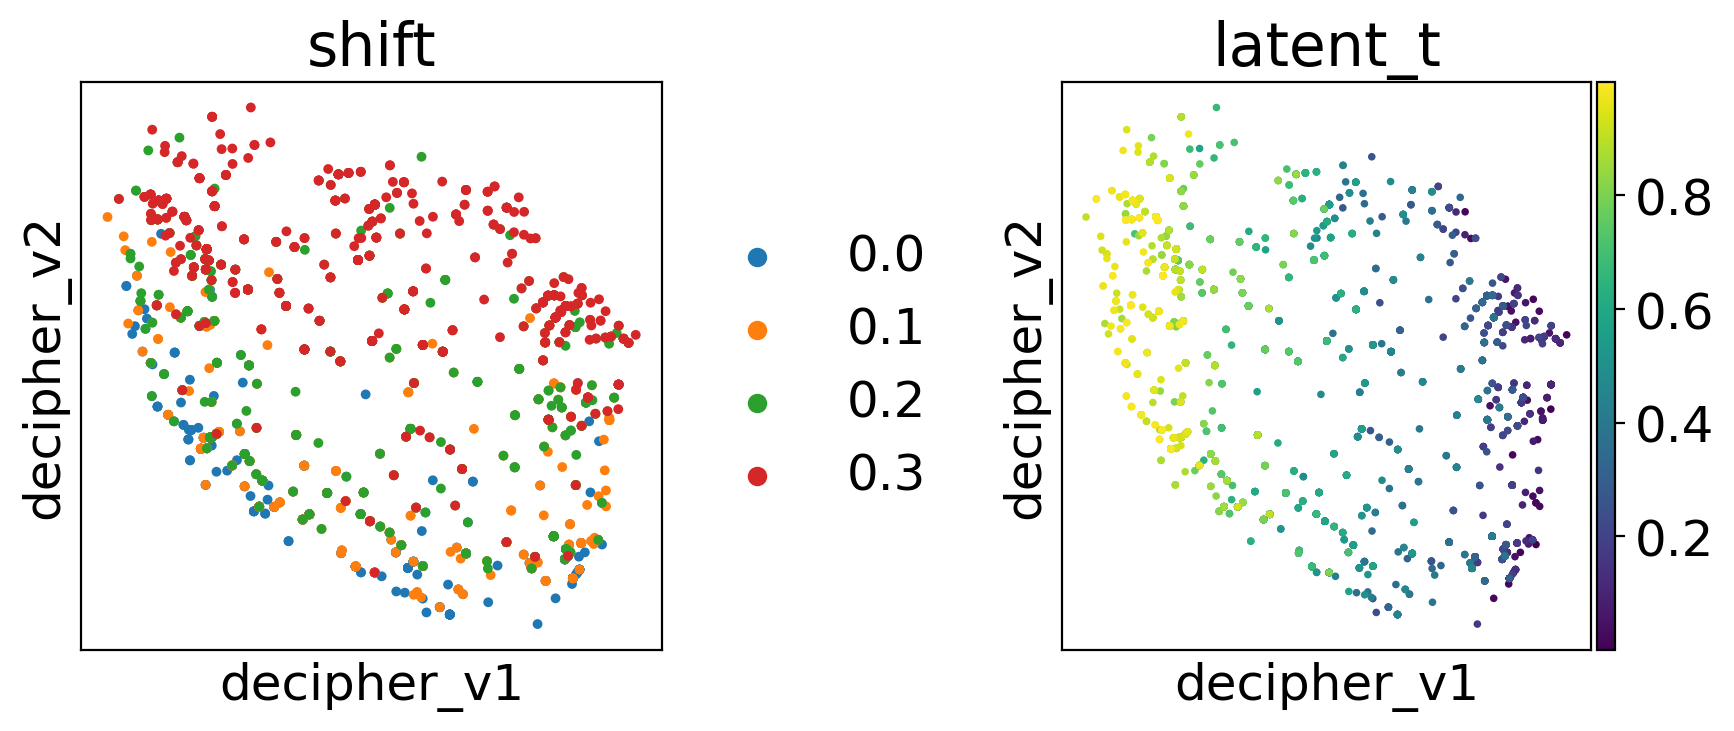

In [27]:
visualize_shift_latentt(adata1)

Epoch 70 (batch 20/20) | | train elbo: 35.36 (last epoch: 35.75) | val ll: 45.93:   7%|▋         | 70/1000 [00:12<02:50,  5.47it/s]2026-06-30 16:54:59,225 | INFO : Early stopping has been triggered.
2026-06-30 16:54:59,227 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-30 16:54:59,227 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-30 16:54:59,227 | INFO : Saving decipher model with run_id 2026-06-30-16-54-59-succulent-calm-soup.


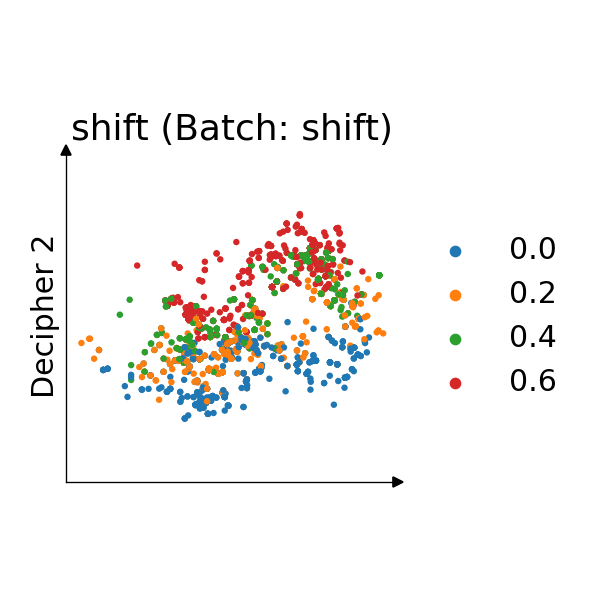

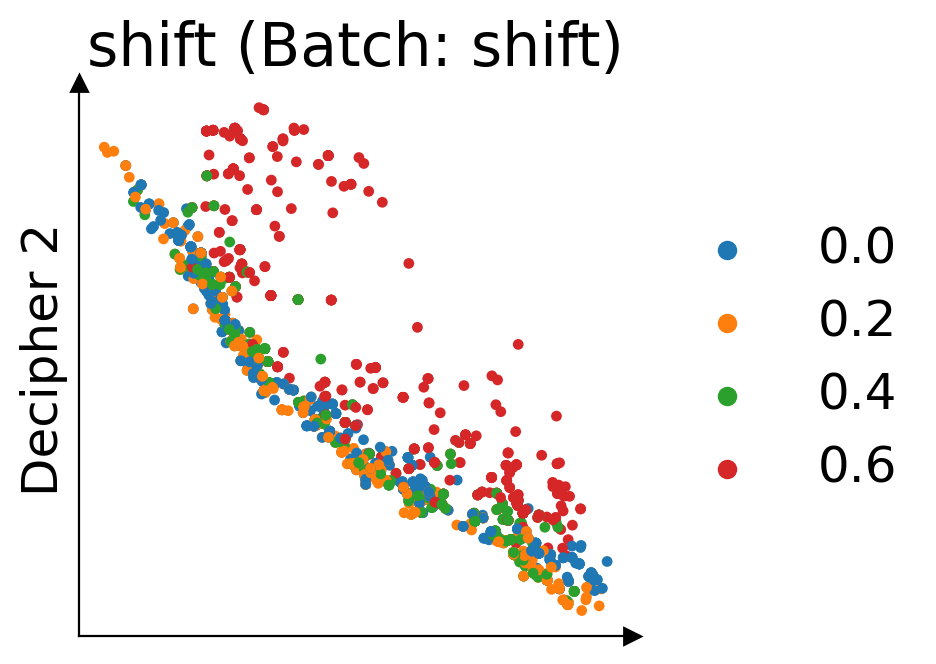

In [28]:
adata2, d2, val2 = run_pipeline("0630_vz_0.20_0.40_0.60.h5ad", shift = "v-to-z")

In [29]:
adata2.layers['counts'].shape

(2000, 50)

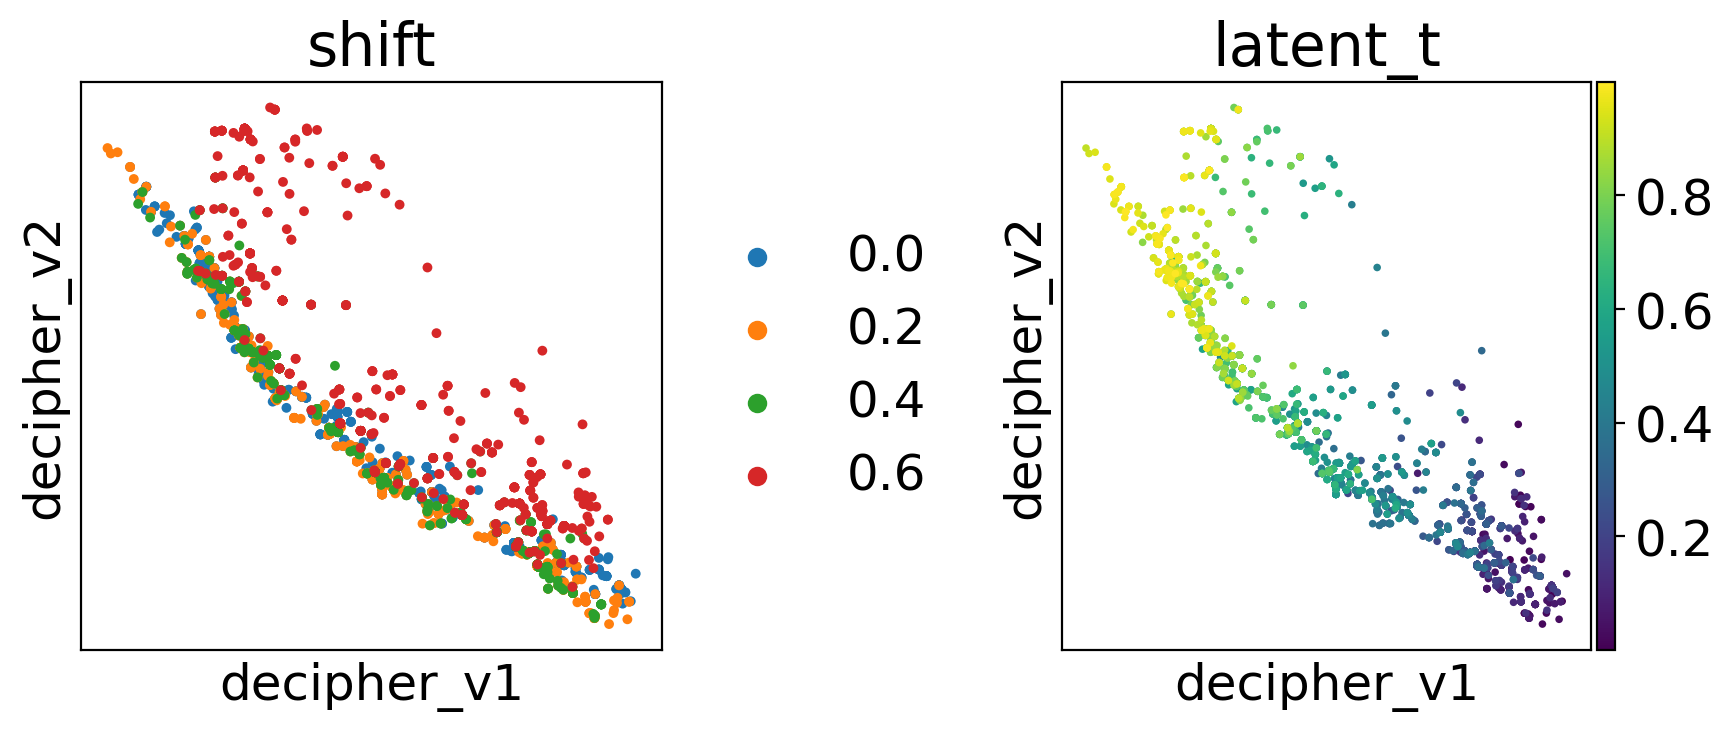

In [30]:
visualize_shift_latentt(adata2)

v[:,0] vs latent_t: Spearman ρ = -0.945, p = 0.00e+00
v[:,1] vs latent_t: Spearman ρ = 0.327, p = 3.54e-51


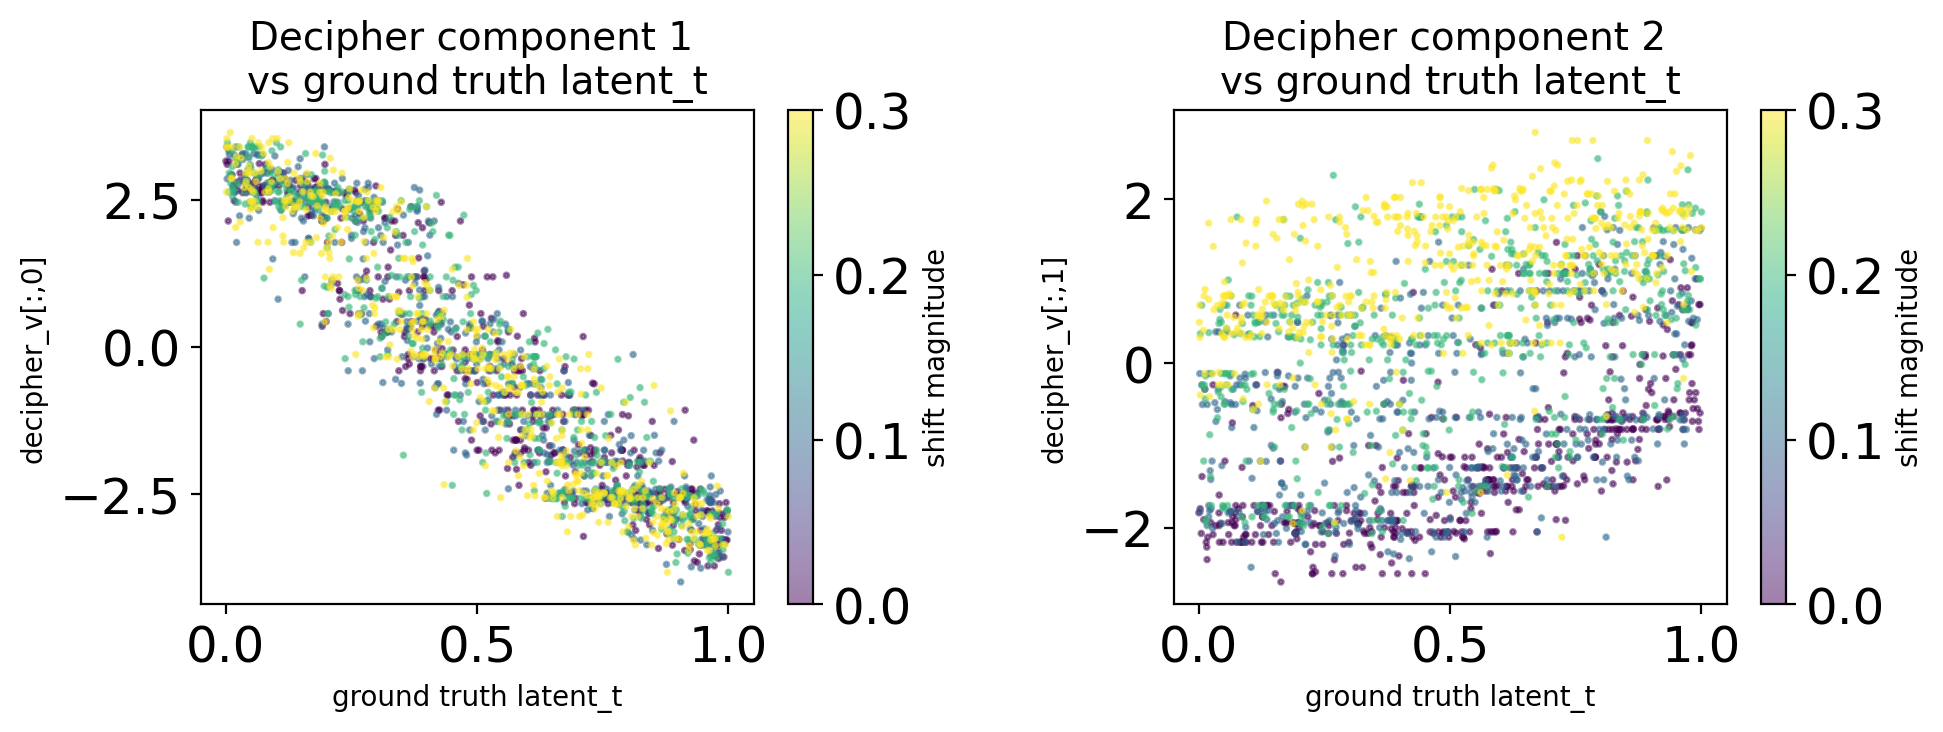

In [31]:
import scanpy as sc   # scanpy stays as sc
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

v = adata1.obsm["decipher_v"]
ground_t = adata1.obs["latent_t"].values

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5*2, 4))
for i in range(v.shape[1]):
    rho, pval = spearmanr(v[:, i], ground_t)
    print(f"v[:,{i}] vs latent_t: Spearman ρ = {rho:.3f}, p = {pval:.2e}")
    ax = axes[i]
    scatter = ax.scatter(                       # renamed from sc → scatter
        ground_t, v[:, i],
        c=adata1.obs["shift"].values, cmap="viridis",
        s=3, alpha=0.5,
    )
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("shift magnitude", fontsize=10)
    ax.set_title(f"Decipher component {i+1} \nvs ground truth latent_t", fontsize=14)
    ax.set_xlabel("ground truth latent_t", fontsize=10)
    ax.set_ylabel(f"decipher_v[:,{i}]", fontsize=10)
plt.tight_layout()
plt.show()

## version 2

Epoch 63 (batch 22/22) | | train elbo: 33.50 (last epoch: 33.29) | val ll: 43.01:   6%|▋         | 63/1000 [00:15<03:48,  4.11it/s]2026-06-30 16:56:08,025 | INFO : Early stopping has been triggered.
2026-06-30 16:56:08,027 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-30 16:56:08,027 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-30 16:56:08,028 | INFO : Saving decipher model with run_id 2026-06-30-16-56-08-tractable-yellow-waffle.


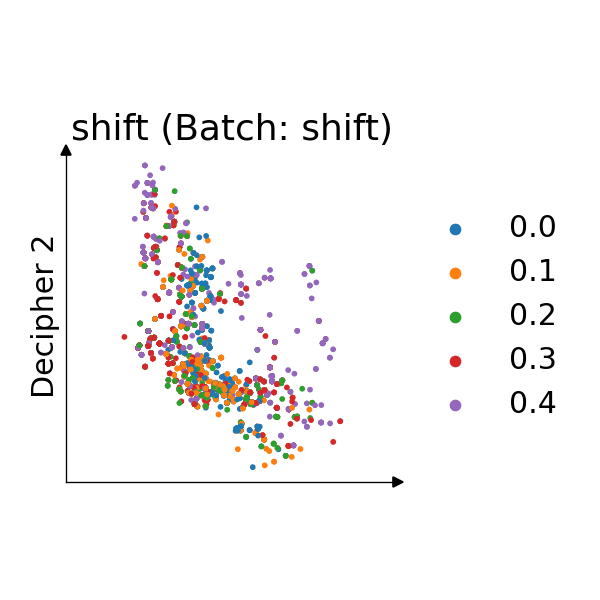

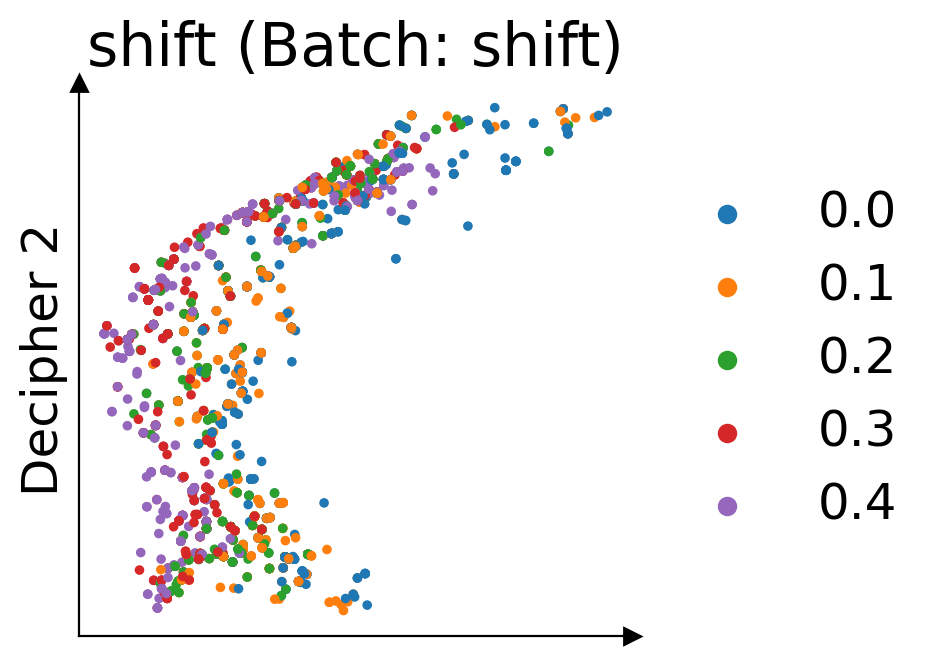

In [32]:
adata1, d1, val1 = run_pipeline("0626_vz_0.10_0.20_0.30_0.40.h5ad", shift="v-to-z")

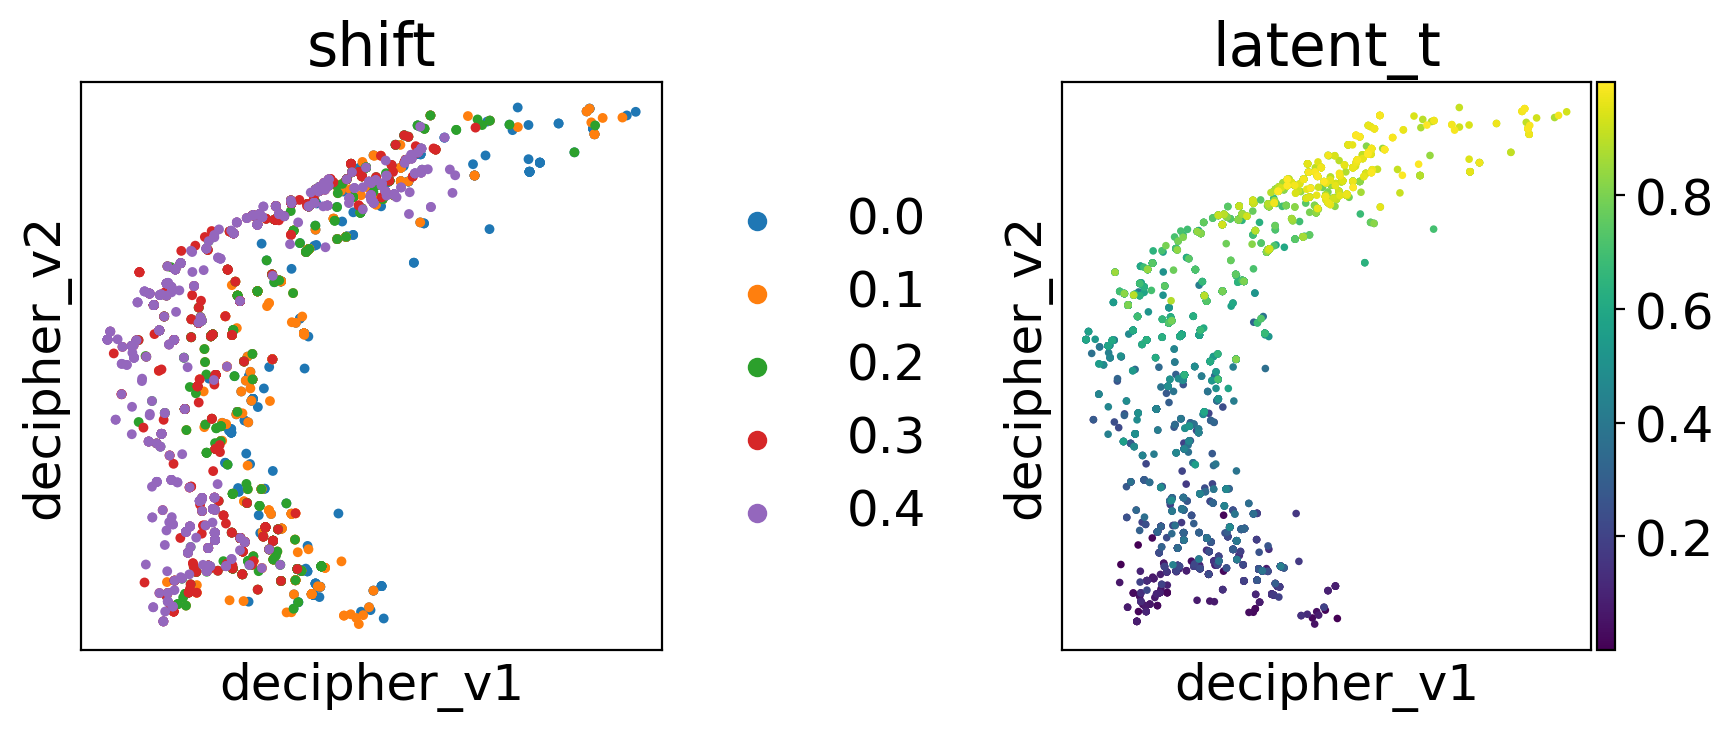

In [33]:
visualize_shift_latentt(adata1)

v[:,0] vs latent_t: Spearman ρ = 0.547, p = 1.77e-195
v[:,1] vs latent_t: Spearman ρ = 0.946, p = 0.00e+00


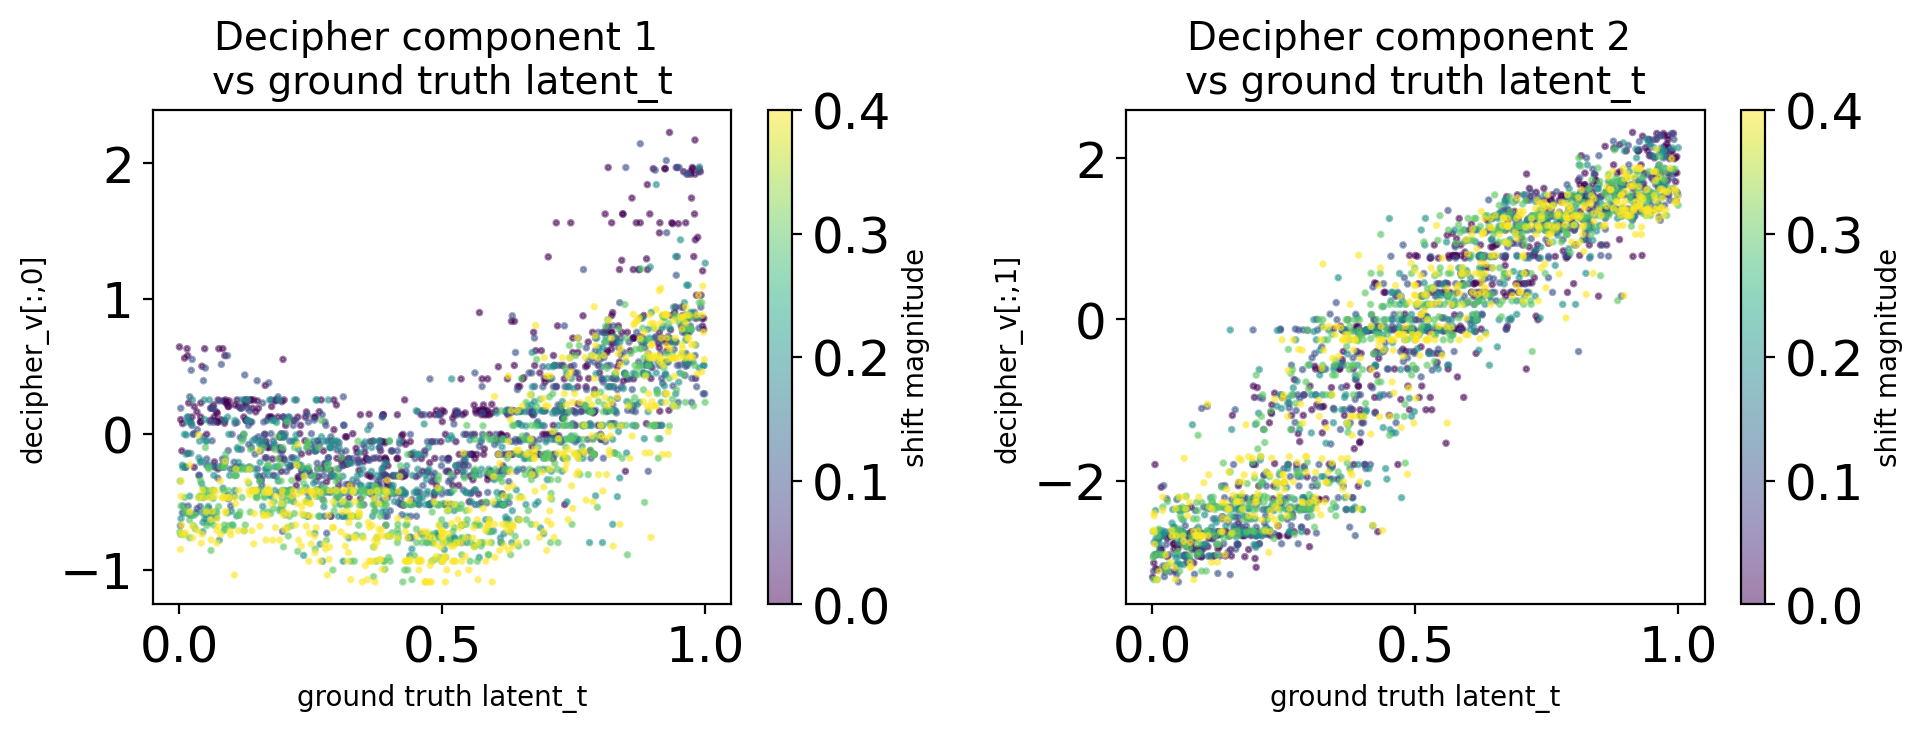

In [34]:
import scanpy as sc   # scanpy stays as sc
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

v = adata1.obsm["decipher_v"]
ground_t = adata1.obs["latent_t"].values

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5*2, 4))
for i in range(v.shape[1]):
    rho, pval = spearmanr(v[:, i], ground_t)
    print(f"v[:,{i}] vs latent_t: Spearman ρ = {rho:.3f}, p = {pval:.2e}")
    ax = axes[i]
    scatter = ax.scatter(                       # renamed from sc → scatter
        ground_t, v[:, i],
        c=adata1.obs["shift"].values, cmap="viridis",
        s=3, alpha=0.5,
    )
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("shift magnitude", fontsize=10)
    ax.set_title(f"Decipher component {i+1} \nvs ground truth latent_t", fontsize=14)
    ax.set_xlabel("ground truth latent_t", fontsize=10)
    ax.set_ylabel(f"decipher_v[:,{i}]", fontsize=10)
plt.tight_layout()
plt.show()

In [35]:
import numpy as np
from scipy.stats import spearmanr

results = []
for batch in sorted(adata1.obs["batch"].unique()):
    sub = adata1[adata1.obs["batch"] == batch]
    v = sub.obsm["decipher_v"]
    t = sub.obs["latent_t"].values
    rhos = [abs(spearmanr(v[:, i], t).correlation) for i in range(v.shape[1])]
    results.append({"batch": batch, "shift": sub.obs["shift"].iloc[0], 
                    "max_rho": max(rhos), "v0_rho": rhos[0], "v1_rho": rhos[1]})

import pandas as pd
print(pd.DataFrame(results))

  batch  shift   max_rho    v0_rho    v1_rho
0  0.00    0.0  0.948112  0.552123  0.948112
1  0.10    0.1  0.942677  0.520286  0.942677
2  0.20    0.2  0.947509  0.506624  0.947509
3  0.30    0.3  0.947981  0.570017  0.947981
4  0.40    0.4  0.940720  0.638283  0.940720


v[:,0] vs latent_t: Spearman ρ = 0.946, p = 0.00e+00
v[:,1] vs latent_t: Spearman ρ = 0.048, p = 1.64e-02


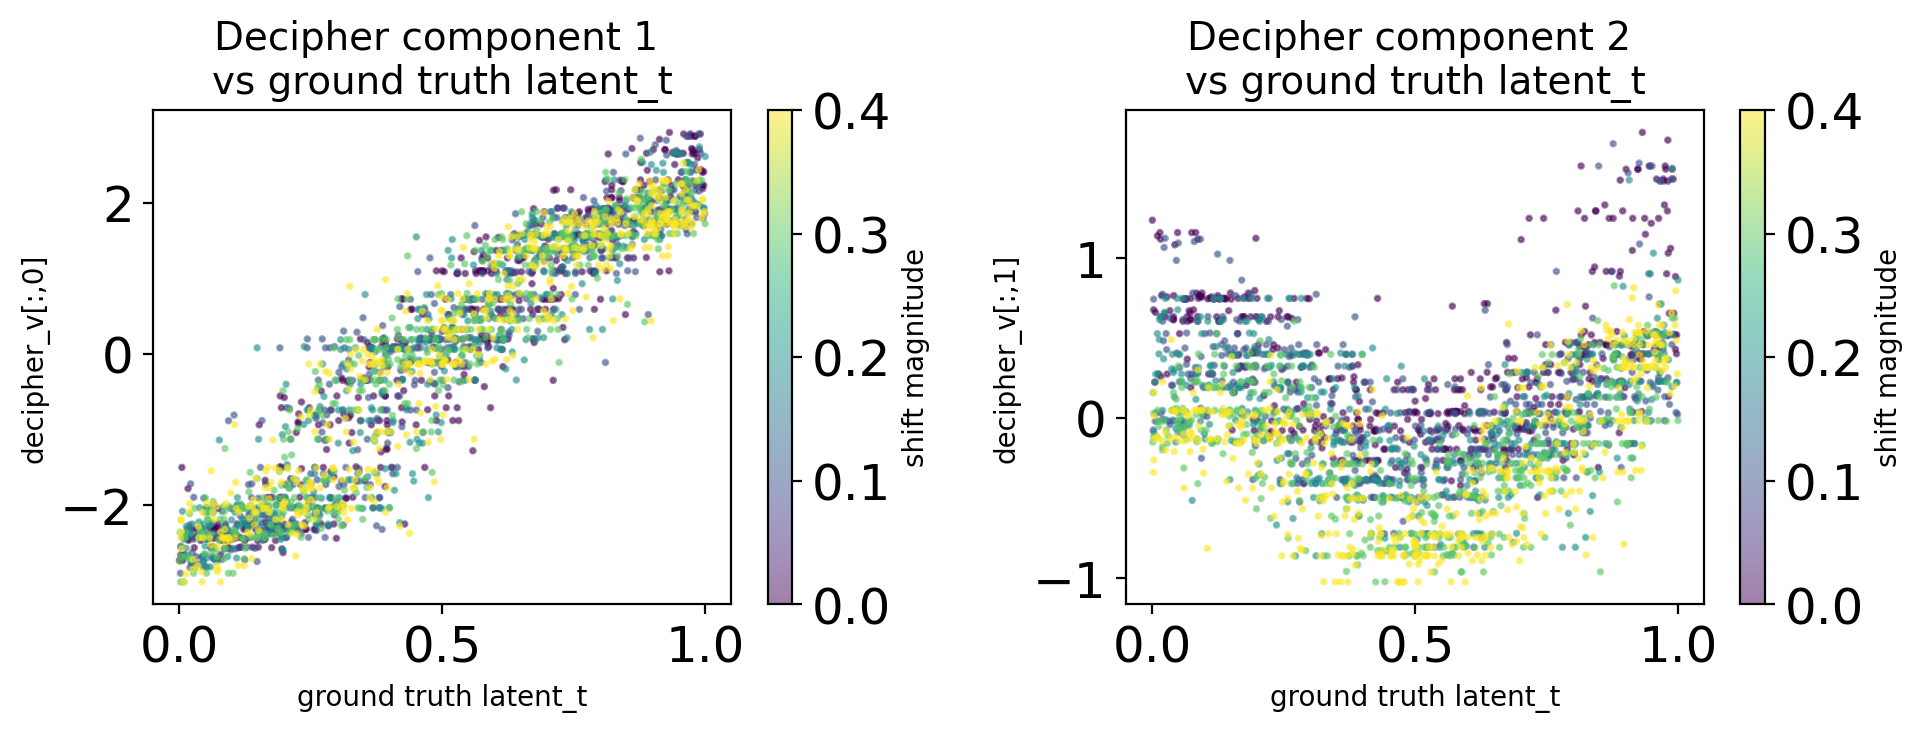

In [36]:
from sklearn.decomposition import PCA

v = adata1.obsm["decipher_v"]
v_rotated = PCA(n_components=2).fit_transform(v)

# now v_rotated[:, 0] is the dominant pseudotime axis

import scanpy as sc   # scanpy stays as sc
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

v = v_rotated
ground_t = adata1.obs["latent_t"].values

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5*2, 4))
for i in range(v.shape[1]):
    rho, pval = spearmanr(v[:, i], ground_t)
    print(f"v[:,{i}] vs latent_t: Spearman ρ = {rho:.3f}, p = {pval:.2e}")
    ax = axes[i]
    scatter = ax.scatter(                       # renamed from sc → scatter
        ground_t, v[:, i],
        c=adata1.obs["shift"].values, cmap="viridis",
        s=3, alpha=0.5,
    )
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("shift magnitude", fontsize=10)
    ax.set_title(f"Decipher component {i+1} \nvs ground truth latent_t", fontsize=14)
    ax.set_xlabel("ground truth latent_t", fontsize=10)
    ax.set_ylabel(f"decipher_v[:,{i}]", fontsize=10)
plt.tight_layout()
plt.show()

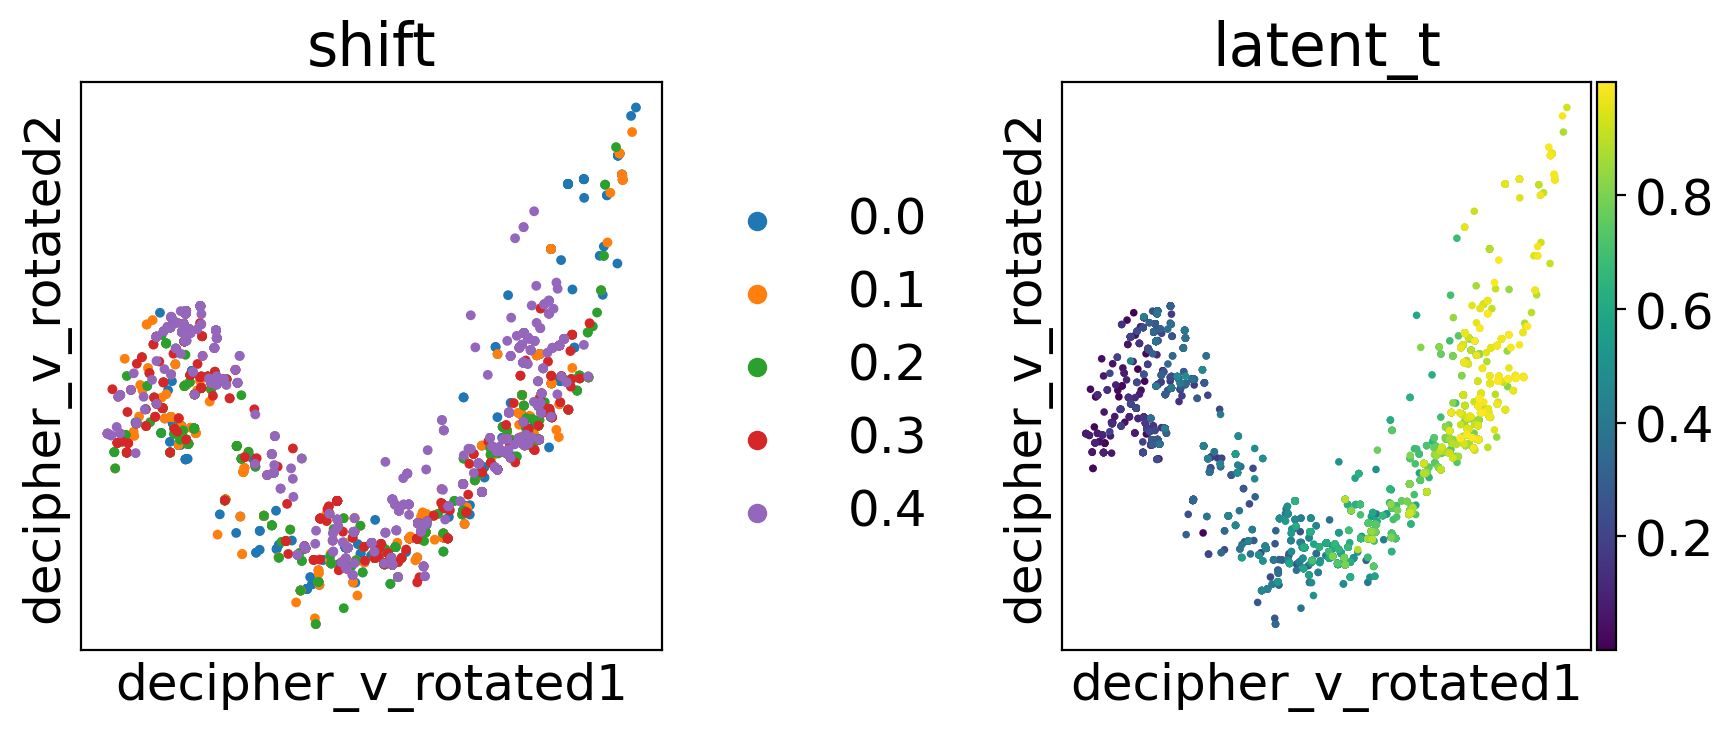

In [66]:
from scipy.stats import spearmanr

v = adata1.obsm["decipher_v"]
v_rotated = PCA(n_components=2).fit_transform(v)
# Order PCs by |Spearman with latent_t|, descending
rhos = [abs(spearmanr(v_rotated[:, i], adata1.obs["latent_t"]).correlation) 
        for i in range(v_rotated.shape[1])]
order = np.argsort(rhos)[::-1]   # largest |ρ| first
v_rotated = v_rotated[:, order]
adata1.obsm["decipher_v_rotated"] = v_rotated

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
sc.pl.embedding(adata1, basis="decipher_v_rotated", color="shift",
                show=False, ax=axes[0], size=50)
sc.pl.embedding(adata1, basis="decipher_v_rotated", color="latent_t",
                show=False, ax=axes[1], size=30)
plt.tight_layout()
plt.show()

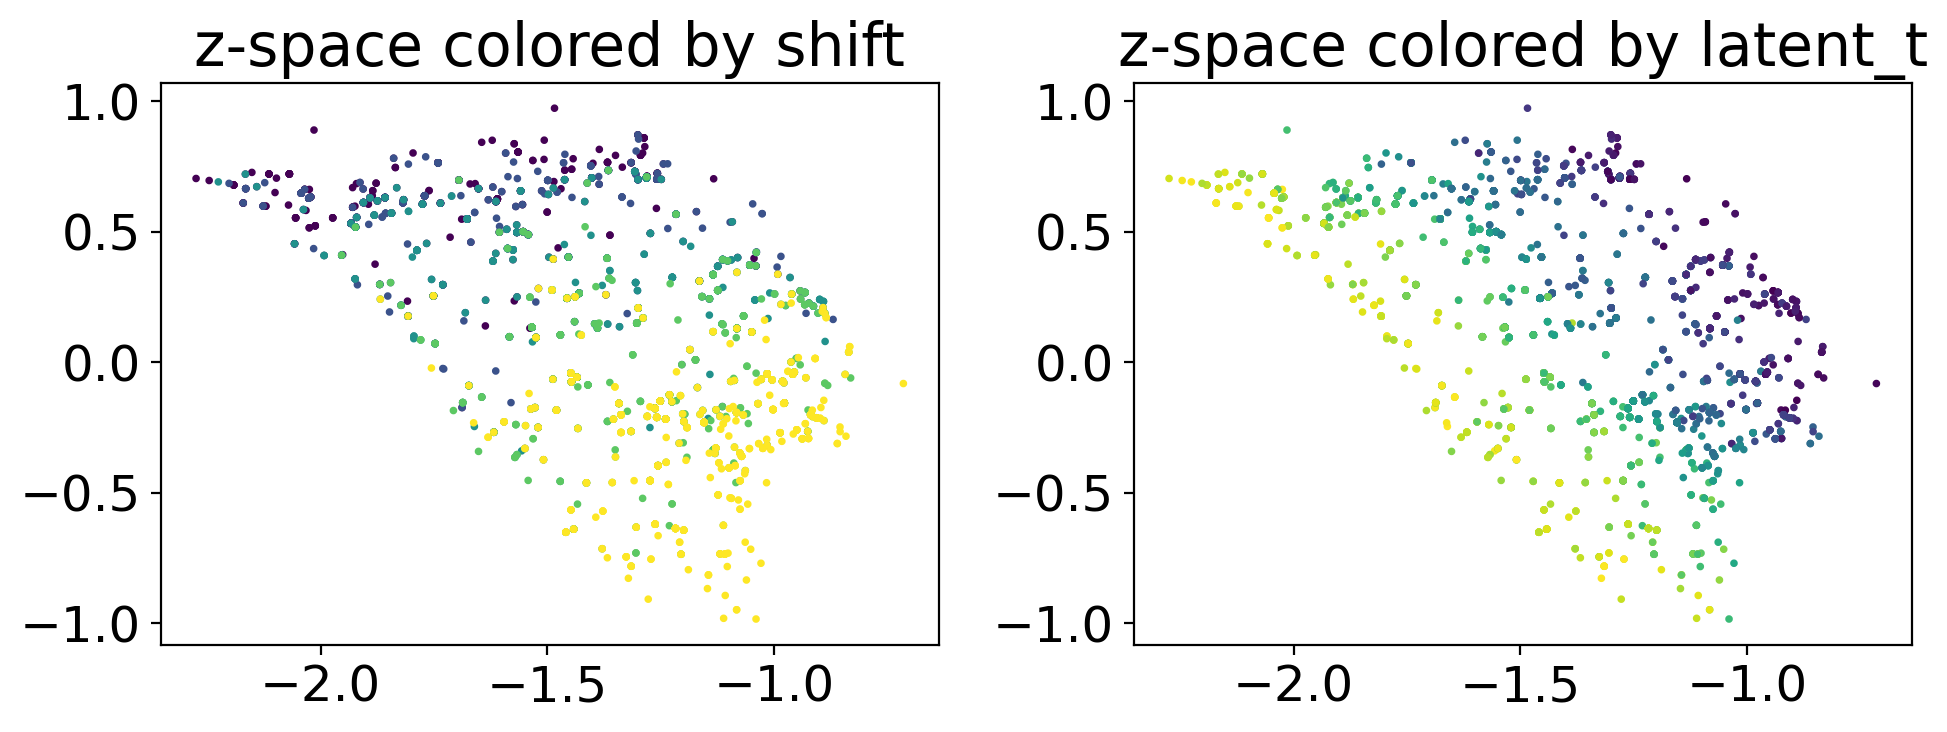

In [37]:
z = adata1.obsm["decipher_z"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(z[:, 0], z[:, 1], c=adata1.obs["shift"].values, cmap="viridis", s=3)
axes[0].set_title("z-space colored by shift")

axes[1].scatter(z[:, 0], z[:, 1], c=adata1.obs["latent_t"].values, cmap="viridis", s=3)
axes[1].set_title("z-space colored by latent_t")

plt.tight_layout()
plt.show()

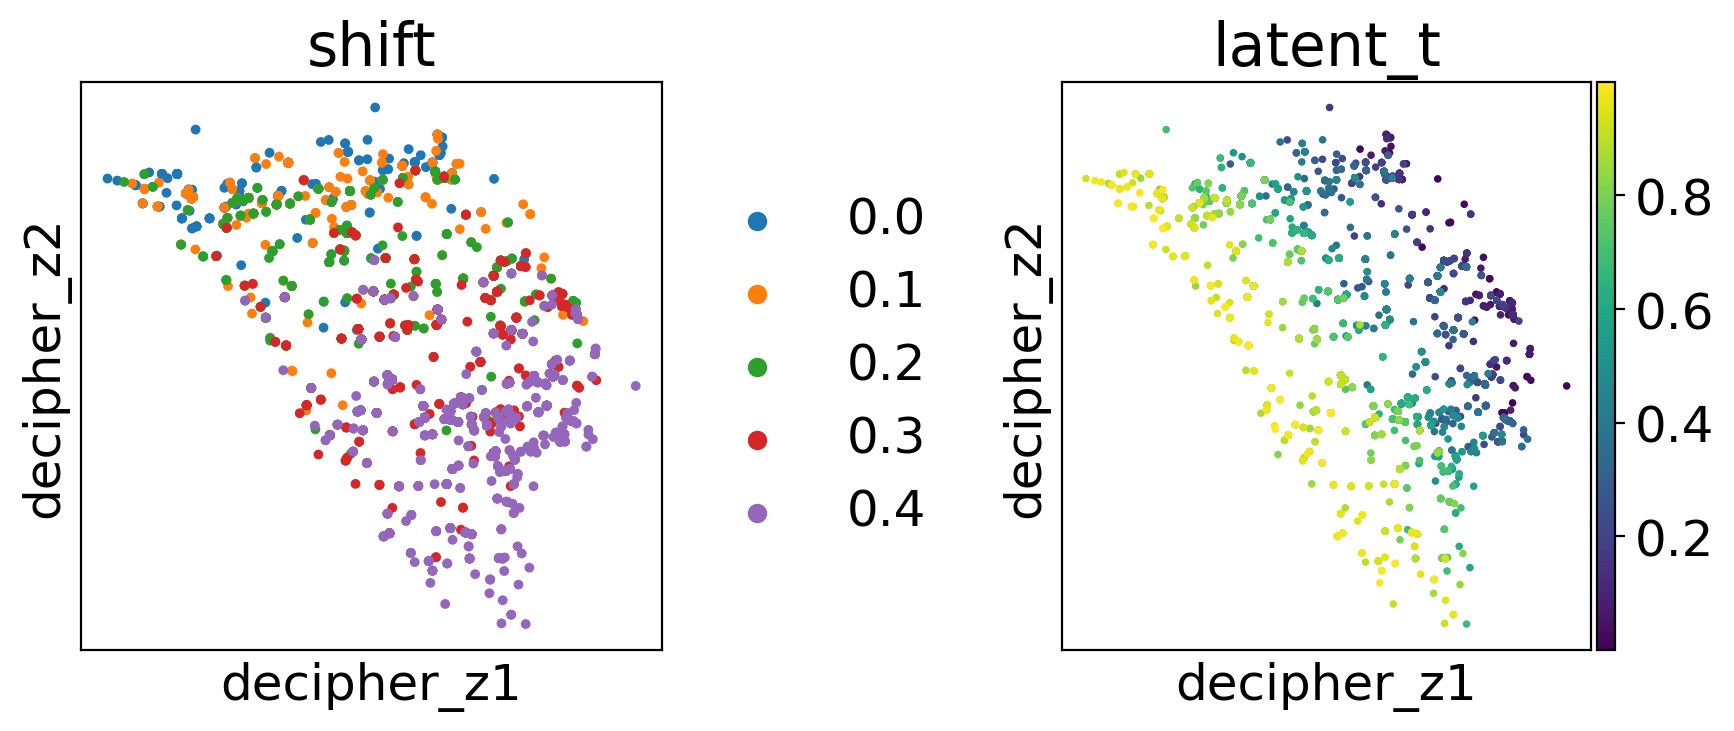

In [38]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
sc.pl.embedding(adata1, basis="decipher_z", color="shift",
                show=False, ax=axes[0], size=50)
sc.pl.embedding(adata1, basis="decipher_z", color="latent_t",
                show=False, ax=axes[1], size=30)
plt.tight_layout()
plt.show()

In [64]:
# Perform Leiden clustering
dc_vz.tl.cell_clusters(adata1, leiden_resolution = 0.05, n_neighbors = 25, seed=341)
adata1.obs['decipher_clusters'].nunique()

2026-06-30 17:51:34,748 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-06-30 17:51:34,748 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.


2026-06-30 17:51:34,780 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 0.05.
2026-06-30 17:51:34,919 | INFO : Added `.obs['decipher_clusters']`: the cluster labels.


36

In [ ]:
# Print number of cells per cluster
adata1.obs['decipher_clusters'].value_counts().sort_index()

#Which cluster does a cell belong to
adata1.obs["decipher_clusters"]

#Ground truth for each cell, or differentiation progress
adata1.obs["latent_t"]

#Group by clusters, and then take average of latent_t
adata1.obs.groupby("decipher_clusters")["latent_t"].mean()

#Group by clusters, take average of latent_t, and then list in ascending order
adata1.obs.groupby("decipher_clusters")["latent_t"].mean().sort_values()

#Group by clusters, take average of latent_t, list in asc. order, and then turn into list
ground_truths = adata1.obs.groupby("decipher_clusters")["latent_t"].mean().sort_values().index.tolist()


In [92]:
# Keep clusters with enough cells
filtered_clusters = adata1.obs["decipher_clusters"].value_counts() > 10

# Apply mask
filtered_cluster_ids = set(filtered_clusters[filtered_clusters].index)

ground_truths = adata1.obs.groupby("decipher_clusters")["latent_t"].mean().sort_values().index.tolist()
ground_truths = [c for c in ground_truths if c in filtered_cluster_ids]

In [ ]:
# Computes points that accumulate to form a piecewise linear path through decipher-v space
dc_vz.tl.trajectories(adata1, dc_vz.tl.TConfig("trajectory", cluster_ids_list = ground_truths))

2026-06-30 18:32:13,933 | INFO : Trajectory trajectory : ['6', '1', '17', '20', '34', '7', '26', '9', '27', '5', '3', '2', '23', '31', '24', '30', '33', '18', '12', '14', '19', '13', '4', '29', '25', '28', '22', '10', '11', '16', '15', '32', '21', '8', '0'])
2026-06-30 18:32:13,941 | INFO : Added trajectory trajectory to `adata.uns['decipher']['trajectories']`.


2026-06-30 19:10:42,819 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-30 19:10:42,820 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.


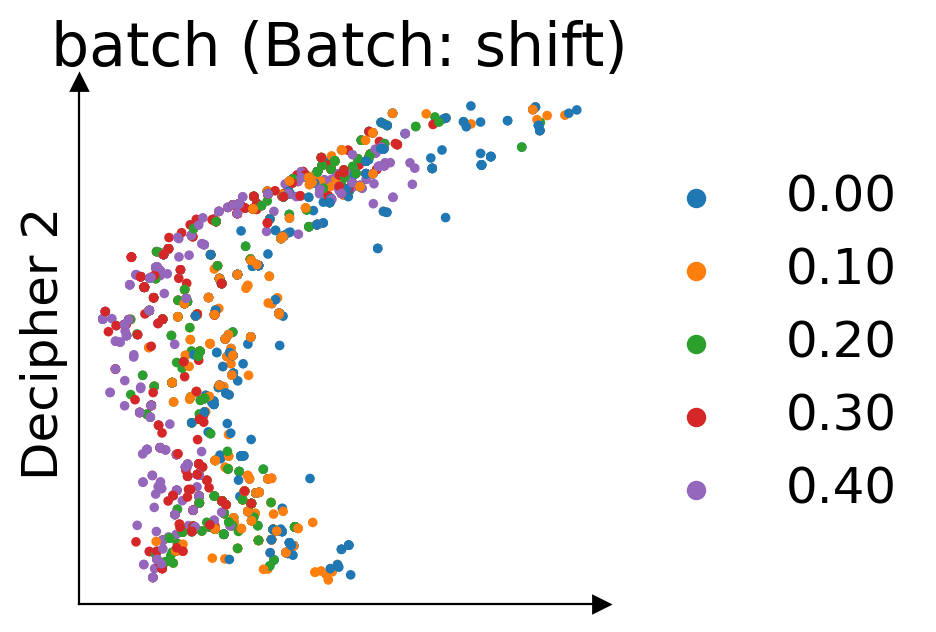

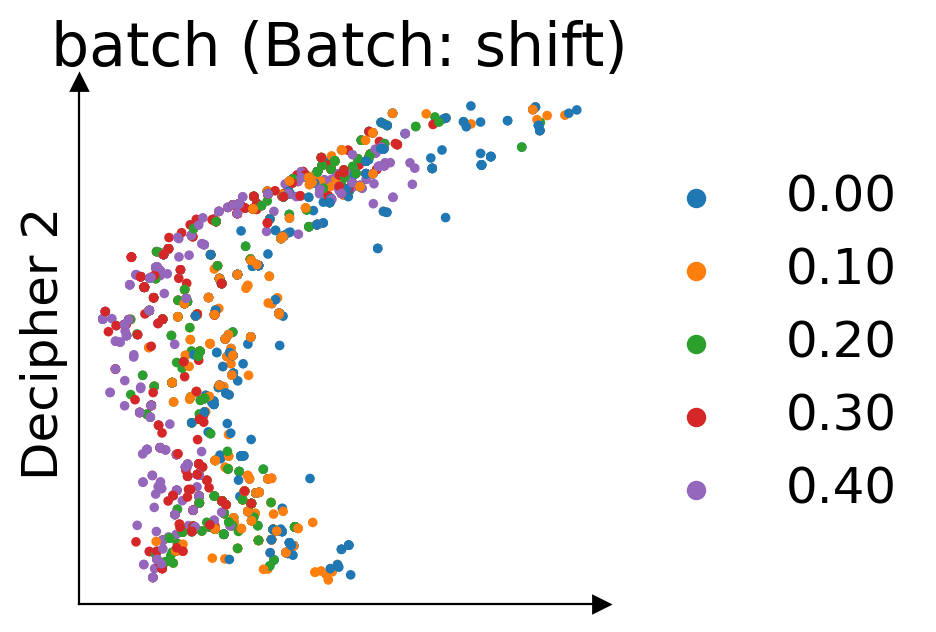

In [117]:
dc_vz.tl.decipher_rotate_space(adata1)
dc_vz.pl.decipher(adata1, color="batch")

In [123]:
dc_vz.tl.decipher_time(adata1)

2026-06-30 19:24:51,888 | INFO : Added `.obs['decipher_time']`: the decipher time of each cell.


In [120]:
# Check that decipher_time was actually populated (not all NaN)
print(adata1.obs["decipher_time"].isna().sum(), "NaN cells")
print(adata1.obs["decipher_time"].describe())

7 NaN cells
count    2493.000000
mean        7.334275
std         4.660167
min         0.090160
25%         2.855058
50%         7.234816
75%        11.830958
max        13.954720
Name: decipher_time, dtype: float64


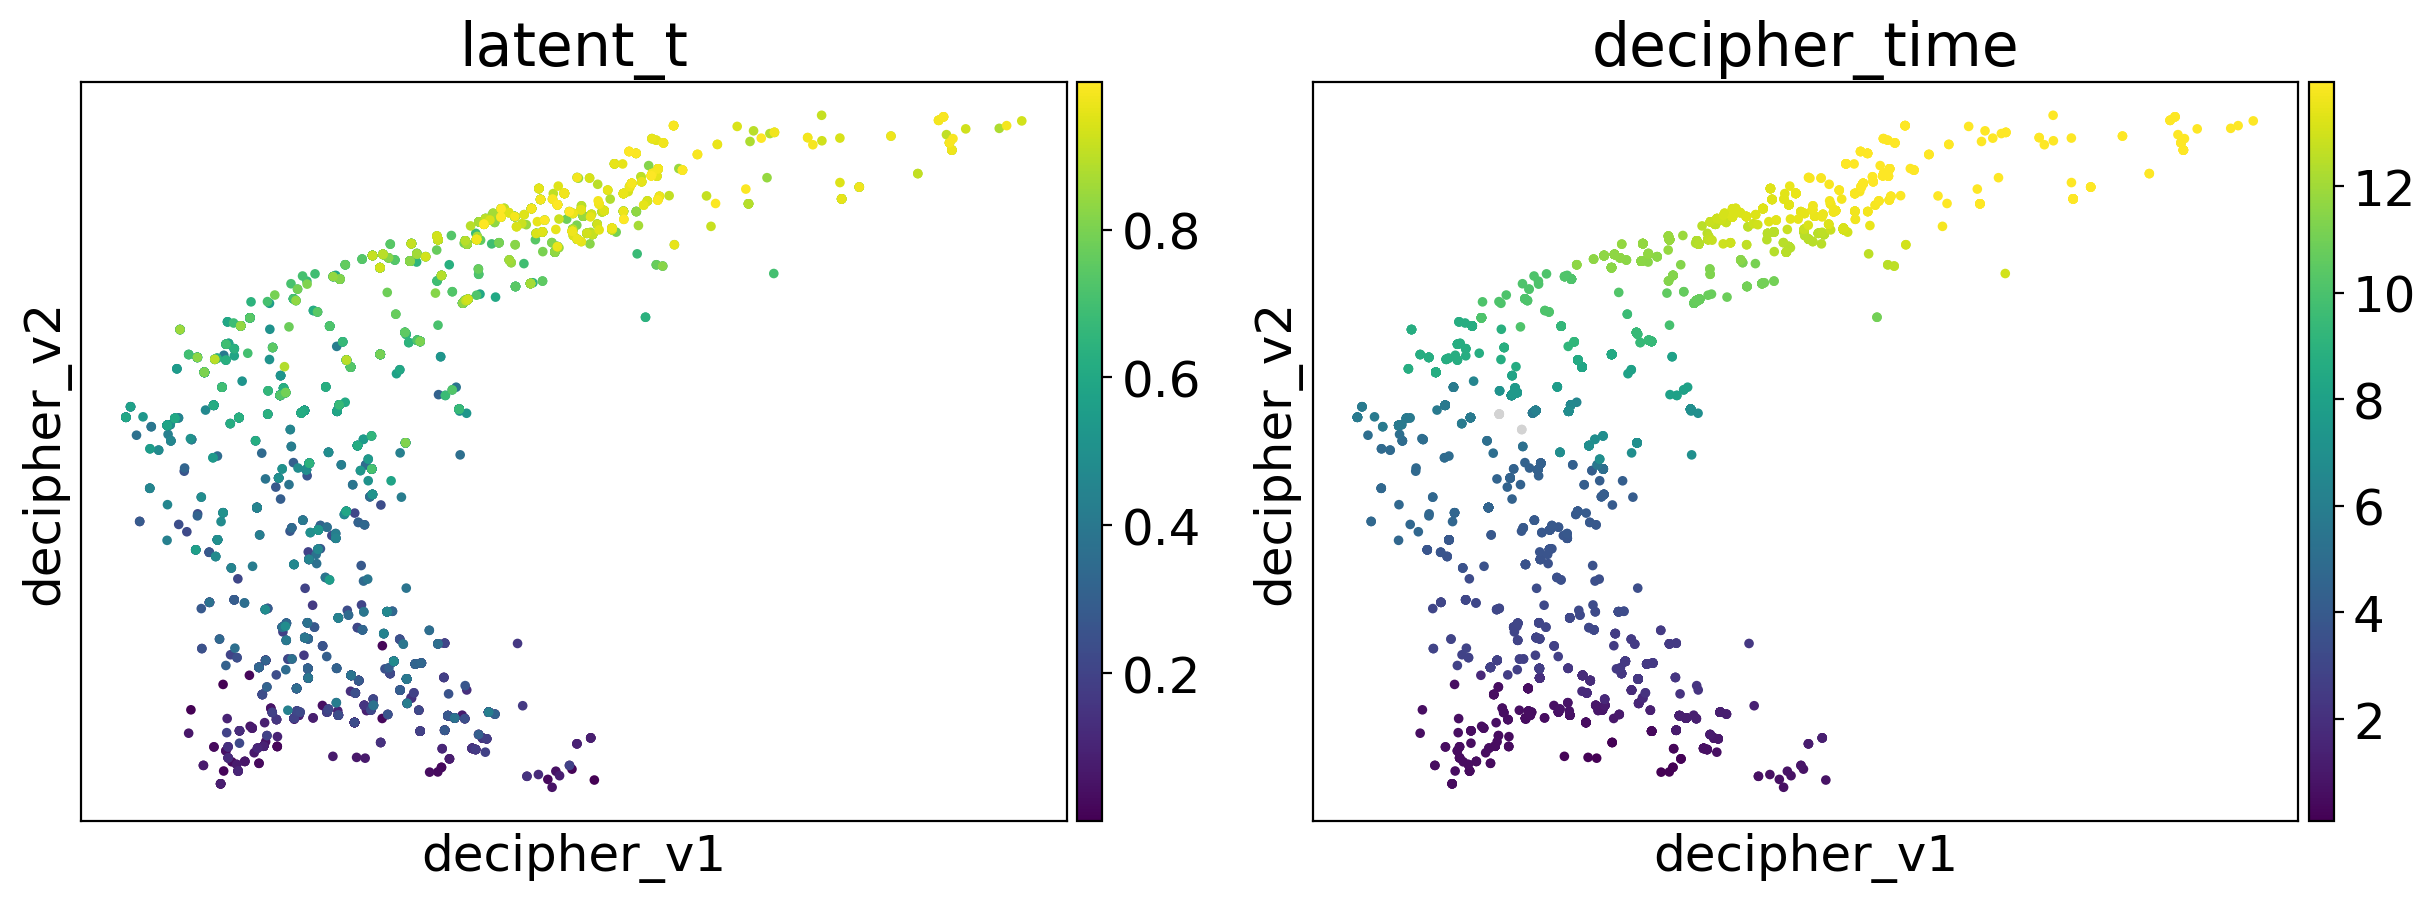

In [126]:
sc.pl.embedding(adata1, basis = "decipher_v", color = ["latent_t", "decipher_time"])

In [122]:
from scipy.stats import spearmanr

for b in sorted(adata1.obs["batch"].unique()):
    mask = adata1.obs["batch"] == b
    # drop NaN cells (those not on trajectory)
    valid = mask & adata1.obs["decipher_time"].notna()
    rho, pval = spearmanr(adata1.obs.loc[valid, "decipher_time"], adata1.obs.loc[valid, "latent_t"])
    print(f"batch={b}  rho={rho:+.4f}  p={pval:.2e}")

batch=0.00  rho=+0.9449  p=1.13e-243
batch=0.10  rho=+0.9429  p=6.42e-239
batch=0.20  rho=+0.9458  p=1.57e-243
batch=0.30  rho=+0.9461  p=1.47e-245
batch=0.40  rho=+0.9391  p=3.50e-233


In [39]:
# 1. Train
#model, val_losses = dc.tl.decipher_train(adata1, batch_key="batch")

# 2. Rotate space — aligns the v components into interpretable axes
dc_vz.tl.decipher_rotate_space(adata1)

# 3. Compute trajectories — this is what populates decipher_time
dc_vz.tl.decipher_trajectory(adata1)

2026-06-30 16:57:22,628 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-30 16:57:22,629 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.


AttributeError: module 'decipher_vz.tools' has no attribute 'decipher_trajectory'

In [40]:
import scanpy as sc
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# Mask NaN decipher_time (cells not on a trajectory)
mask = adata1.obs["decipher_time"].notna()
adata_valid = adata1[mask]

learned_t = adata_valid.obs["decipher_time"].values
ground_t  = adata_valid.obs["latent_t"].values

# Spearman correlation
rho, pval = spearmanr(learned_t, ground_t)
print(f"Spearman rho: {rho:.3f}, p={pval:.2e}")

# Scatter plot
fig, ax = plt.subplots(figsize=(4, 4))
sc_plot = ax.scatter(ground_t, learned_t, c=adata_valid.obs["shift"].values,
                     cmap="viridis", s=5, alpha=0.6)
plt.colorbar(sc_plot, ax=ax, label="shift magnitude")
ax.set_xlabel("ground truth latent_t")
ax.set_ylabel("decipher_time")
ax.set_title(f"Spearman ρ = {rho:.3f}")
plt.tight_layout()
plt.show()

KeyError: 'decipher_time'

In [41]:
decipher_z = adata1.obsm["decipher_z"]
k_means = KMeans(20)
k_means.fit(decipher_z)
adata1.obs["cluster_latent"] = k_means.labels_

aris = {}
for a in adata1.obs["shift"].unique():
    mask = adata1.obs["shift"] == a
    aris[a] = adjusted_rand_score(
        adata1.obs["cluster_true"][mask],
        adata1.obs["cluster_latent"][mask],
    )
#print(f"[{suffix}] aris values: {aris}")

shift_labels = adata1.obs["shift"]
# sil_values = silhouette_samples(decipher_z, shift_labels)
# df = pd.DataFrame({"silhouette_value": sil_values, "alpha": shift_labels.values})
# print(df.groupby("alpha", observed=True)["silhouette_value"].mean())

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(5*3, 4))
# sc.pl.embedding(adata1, basis="decipher_v", color="shift",
#                 show=False, ax=axes[0], size=30)
sc.pl.embedding(adata1, basis="decipher_v", color="shift",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(adata1, basis="decipher_v", color="cluster_true",
                show=False, ax=axes[1], size=30)
sc.pl.embedding(adata1, basis="decipher_v", color="latent_t",
                show=False, ax=axes[2], size=30)
plt.tight_layout()
plt.show()

KeyError: 'cluster_true'

In [23]:
folder = "/Users/jihyunpark/Documents/Decipher/decipher-bc/Data/Simulated Data/Simulated Adata/z-to-x"
file = "delta_0.40_0.80_1.20.h5ad"
adata3 = sc.read_h5ad(f"{folder}/{file}")
adata3.uns["color_palette"] = None
color_palette = None

Epoch 248 (batch 20/20) | | train elbo: 134.45 (last epoch: 134.61) | val ll: 145.00:  25%|██▍       | 248/1000 [12:31<37:58,  3.03s/it]2026-06-15 18:40:28,070 | INFO : Early stopping has been triggered.


2026-06-15 18:40:28,451 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-15 18:40:28,460 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-15 18:40:28,480 | INFO : Saving decipher model with run_id 2026-06-15-18-40-28-recursive-tranquil-ice.


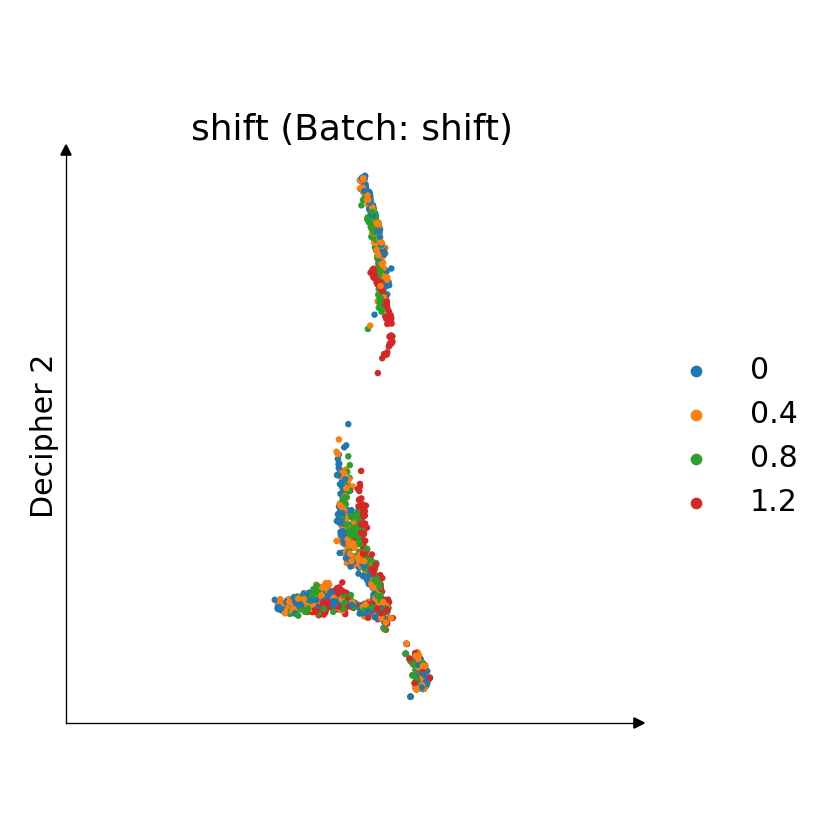

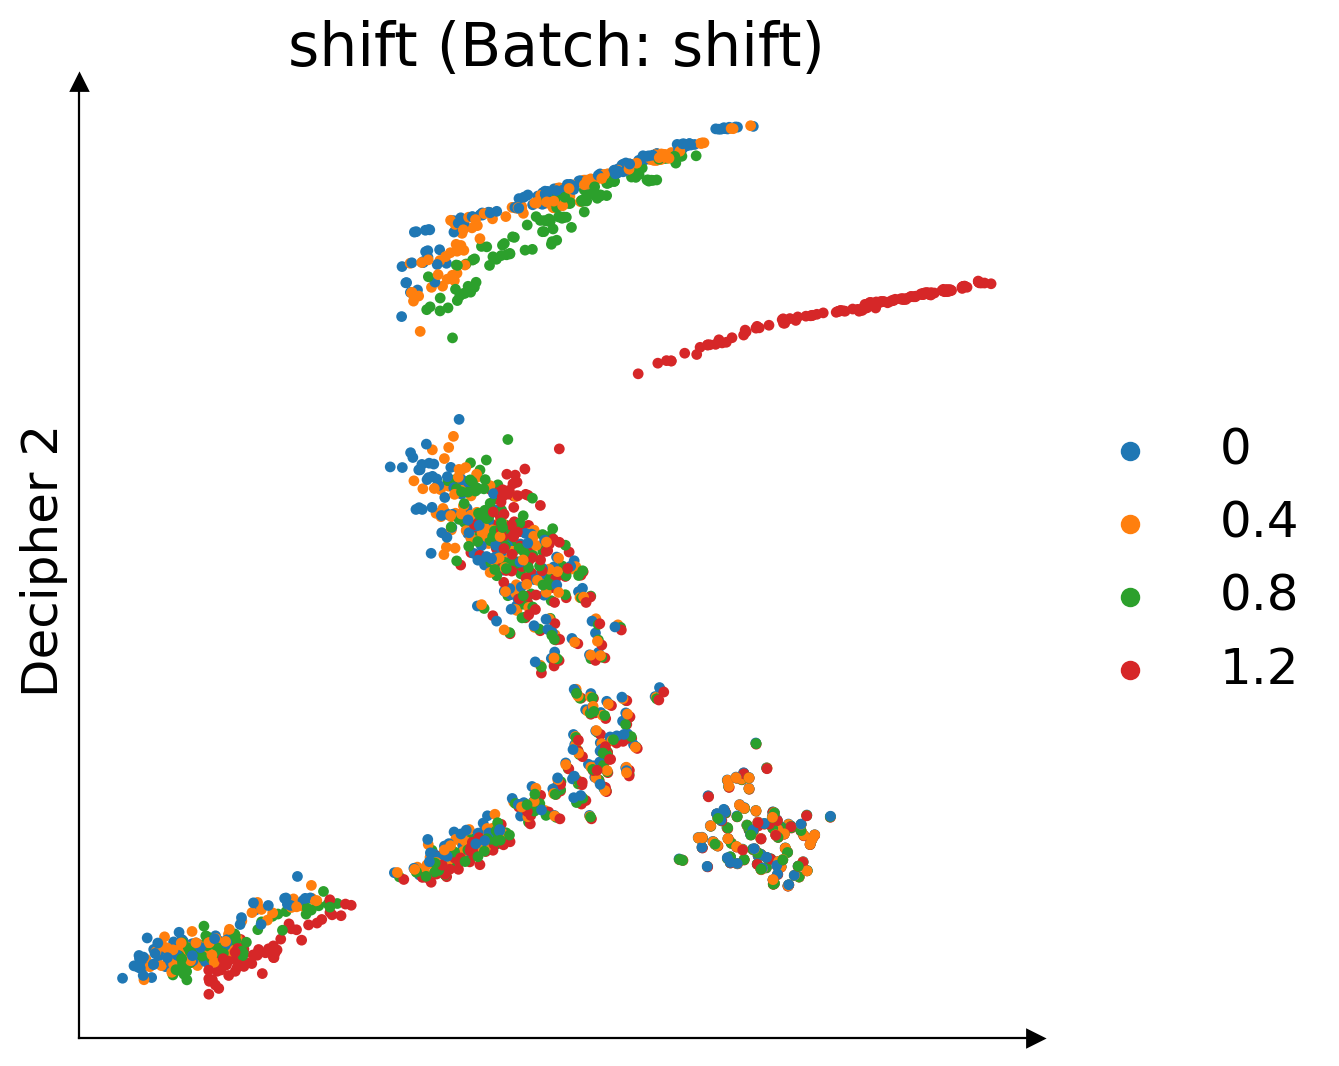

In [24]:
from decipher_vz.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

# Train Decipher
d3, val3 = dc_vz.tl.decipher_train(
    adata3, decipher_config, plot_kwargs= {"color": "shift"}, 
    batch_key="shift",
    plot_every_k_epochs=5,
)

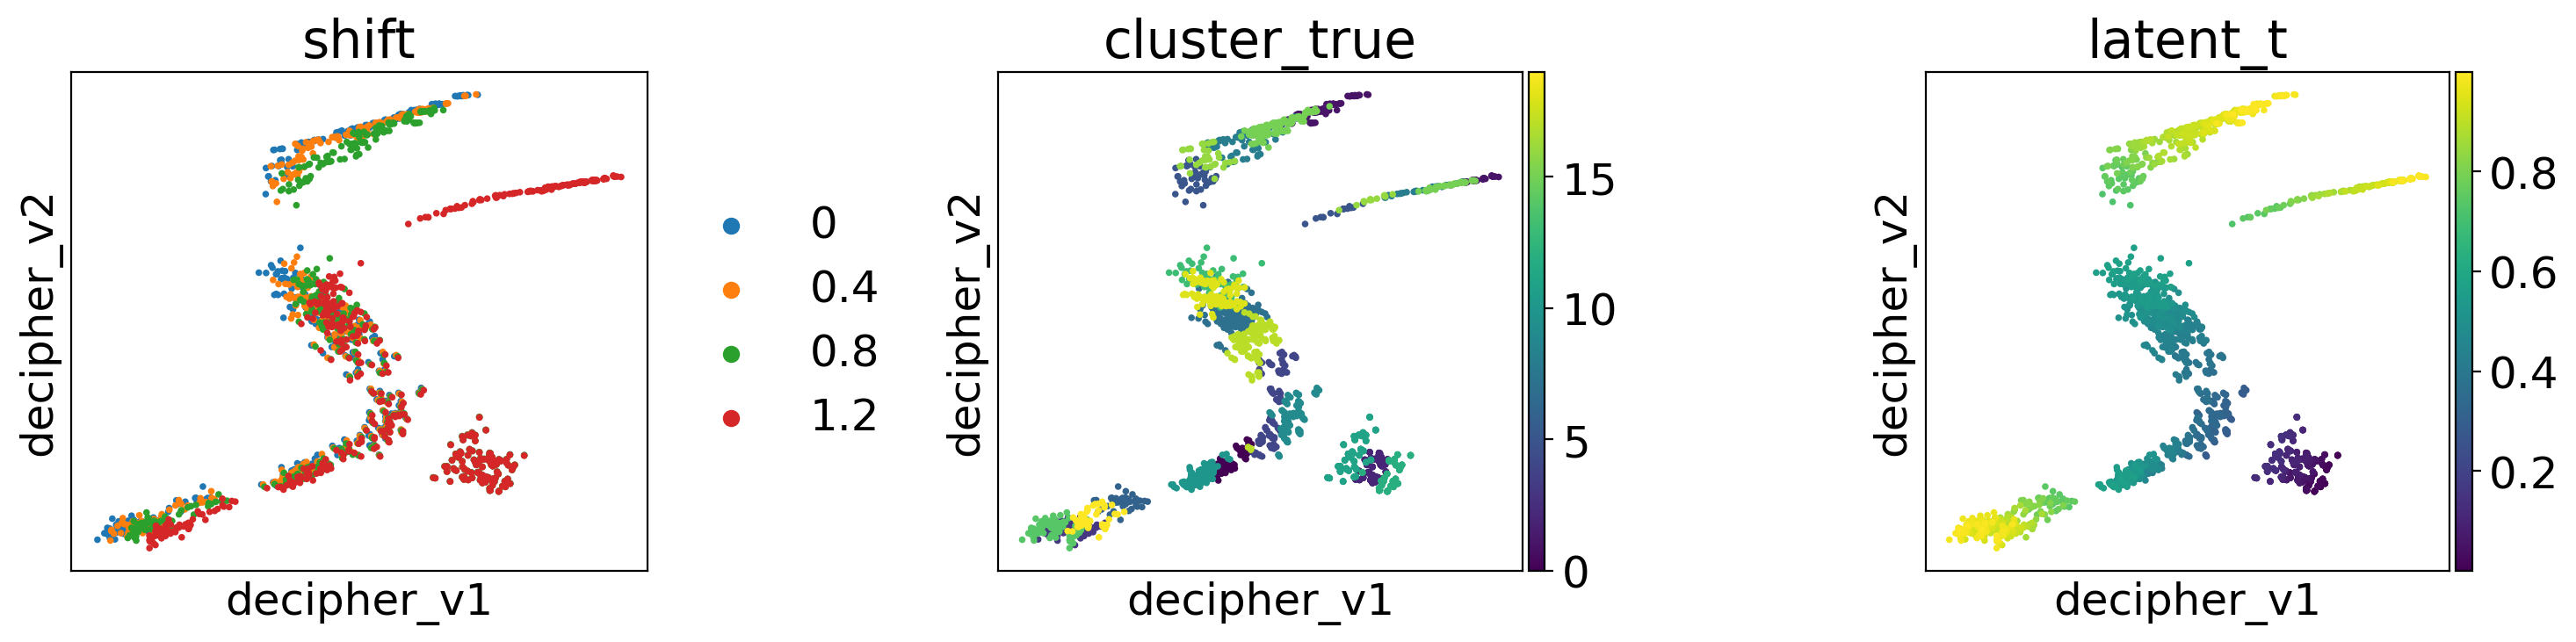

In [25]:
temp = adata3.copy()

decipher_z = temp.obsm["decipher_z"]
k_means = KMeans(20)
k_means.fit(decipher_z)
temp.obs["cluster_latent"] = k_means.labels_

aris = {}
for a in temp.obs["shift"].unique():
    mask = temp.obs["shift"] == a
    aris[a] = adjusted_rand_score(
        temp.obs["cluster_true"][mask],
        temp.obs["cluster_latent"][mask],
    )
#print(f"[{suffix}] aris values: {aris}")

shift_labels = temp.obs["shift"]
# sil_values = silhouette_samples(decipher_z, shift_labels)
# df = pd.DataFrame({"silhouette_value": sil_values, "alpha": shift_labels.values})
# print(df.groupby("alpha", observed=True)["silhouette_value"].mean())

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(5*3, 4))
# sc.pl.embedding(temp, basis="decipher_v", color="shift",
#                 show=False, ax=axes[0], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="shift",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="cluster_true",
                show=False, ax=axes[1], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="latent_t",
                show=False, ax=axes[2], size=30)
plt.tight_layout()
plt.show()

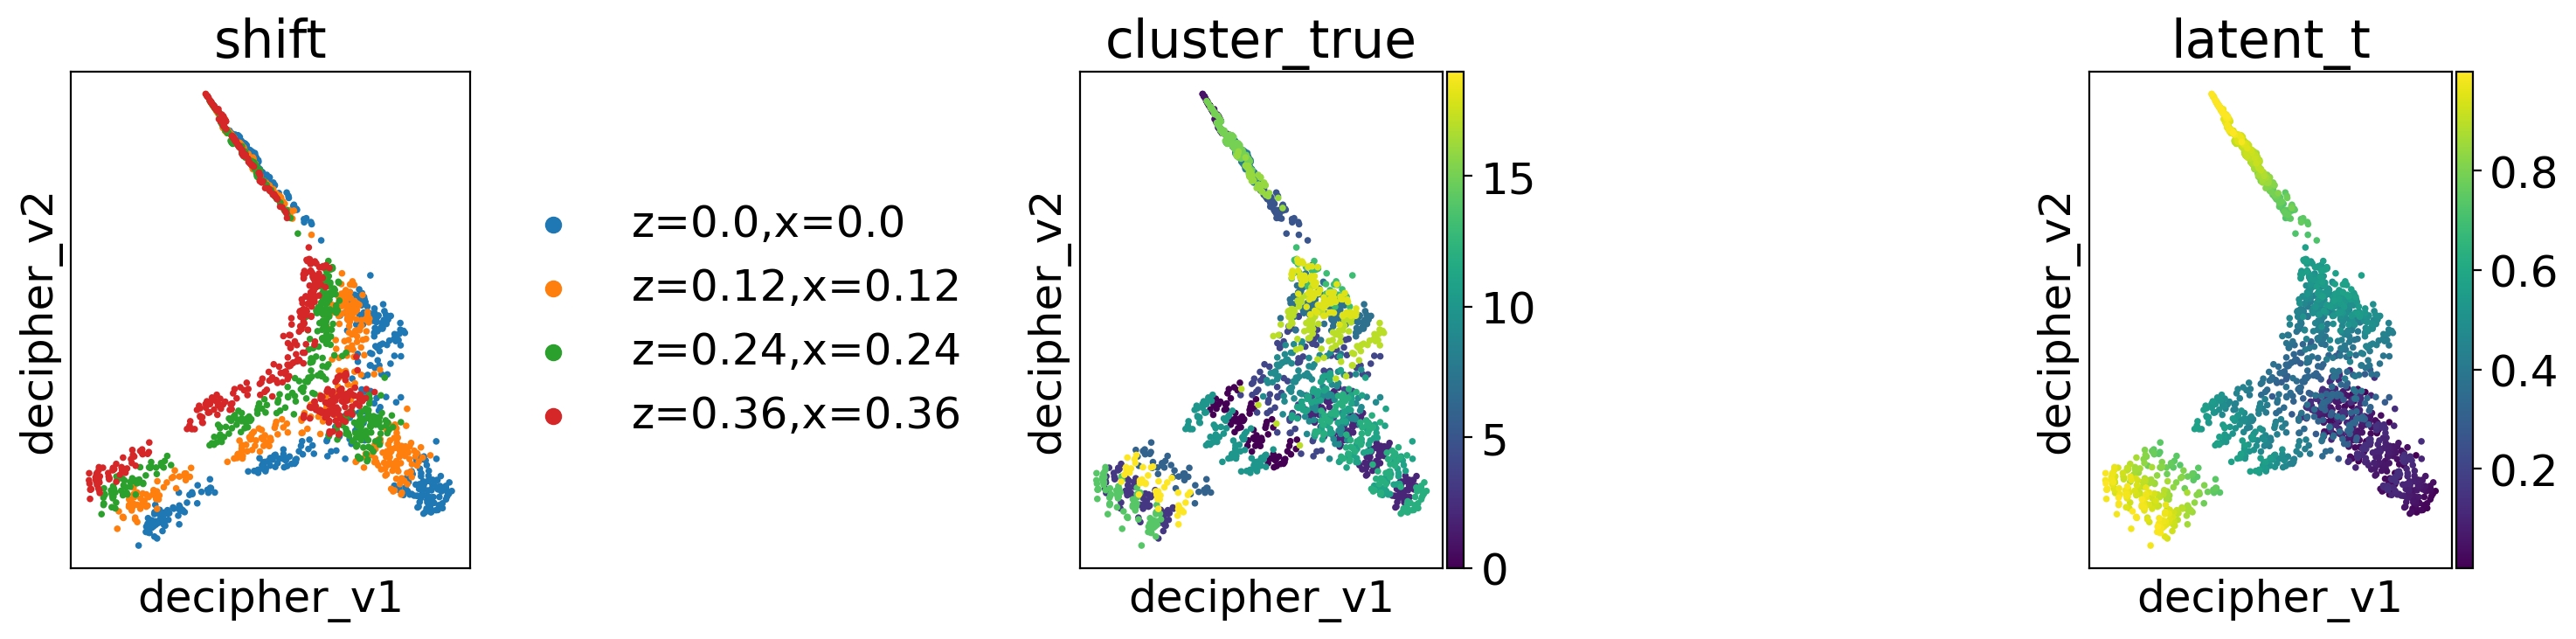

In [22]:
import logging
import pandas as pd
import scanpy as sc
import os
from sklearn.cluster import KMeans

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib as mpl

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.metrics import silhouette_samples


temp = adata2.copy()

decipher_z = temp.obsm["decipher_z"]
k_means = KMeans(20)
k_means.fit(decipher_z)
temp.obs["cluster_latent"] = k_means.labels_

aris = {}
for a in temp.obs["shift"].unique():
    mask = temp.obs["shift"] == a
    aris[a] = adjusted_rand_score(
        temp.obs["cluster_true"][mask],
        temp.obs["cluster_latent"][mask],
    )
#print(f"[{suffix}] aris values: {aris}")

shift_labels = temp.obs["shift"]
# sil_values = silhouette_samples(decipher_z, shift_labels)
# df = pd.DataFrame({"silhouette_value": sil_values, "alpha": shift_labels.values})
# print(df.groupby("alpha", observed=True)["silhouette_value"].mean())

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(5*3, 4))
# sc.pl.embedding(temp, basis="decipher_v", color="shift",
#                 show=False, ax=axes[0], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="shift",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="cluster_true",
                show=False, ax=axes[1], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="latent_t",
                show=False, ax=axes[2], size=30)
plt.tight_layout()
plt.show()

In [ ]:
file = "v_to_z_0.12_0.24_0.36.h5ad"
adata2 = sc.read_h5ad(f"{folder}/{file}")
adata2.uns["color_palette"] = None
color_palette = None

In [18]:
from decipher.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

# Train Decipher
d1, val1 = dc.tl.decipher_train(
    adata1, decipher_config, plot_kwargs= {"color": "shift"}, 
    plot_every_k_epochs=5,
)

2026-06-15 16:36:46,356 | INFO : Added `.obs['decipher_split']`: the Decipher train/validation split.
 200 cells in validation set.
  0%|          | 0/1000 [00:00<?, ?it/s]

ERROR index_select(): self indexing axis dim should be positive
                                  Trace Shapes:           
                                   Param Sites:           
                         decipher$$$dummy_param       0   
                    decipher$$$batch_emb.weight   0   8   
      decipher$$$encoder_x_to_z.layers.0.weight 128  50   
        decipher$$$encoder_x_to_z.layers.0.bias     128   
      decipher$$$encoder_x_to_z.layers.1.weight  20 128   
        decipher$$$encoder_x_to_z.layers.1.bias      20   
 decipher$$$encoder_x_to_z.batch_norms.0.weight     128   
   decipher$$$encoder_x_to_z.batch_norms.0.bias     128   
     decipher$$$encoder_zx_to_v.layers.0.weight 128  60   
       decipher$$$encoder_zx_to_v.layers.0.bias     128   
     decipher$$$encoder_zx_to_v.layers.1.weight   4 128   
       decipher$$$encoder_zx_to_v.layers.1.bias       4   
decipher$$$encoder_zx_to_v.batch_norms.0.weight     128   
  decipher$$$encoder_zx_to_v.batch_norms.0.bias    

In [68]:
# Before choosing what to correct for, measure which covariates actually drive
# separation in the v-space. High silhouette = strong separation = bigger effect.

from sklearn.metrics import silhouette_score

v = adata_combined.obsm['decipher_v'].copy()

# Only score covariates with at least 2 unique values and no NaNs
covariates_to_score = {
    "shift"   : adata_combined.obs["shift"].astype(str),
}

print("\n── Silhouette scores in v-space (higher = stronger separation) ──────────")
silhouette_results = {}
for name, labels in covariates_to_score.items():
    # Drop NaN rows
    mask = labels != "nan"
    if labels[mask].nunique() < 2:
        print(f"  {name:<20} skipped (< 2 unique values)")
        continue
    score = silhouette_score(v[mask], labels[mask], sample_size=5000, random_state=42)
    silhouette_results[name] = score
    print(f"  {name:<25} silhouette = {score:.4f}")  



── Silhouette scores in v-space (higher = stronger separation) ──────────
  shift                     silhouette = -0.0487
